In [1]:
import numpy as np
from matplotlib import pyplot as plt

from common import bsm_St, bsm_put, result, get_beta

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, message="divide by zero encountered in divide")

In [2]:
S=1
r=0.01
t=0
T=2
sigma=0.25

K=1.1
L=0.7

N=365*T
m=100000
dt=(T-t)/N

In [3]:
S_t = bsm_St(S,r,sigma,N,m,T,t)
actualisation=np.exp(-r*np.arange(t+dt,T-t+dt,dt))

------------------------------
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 0.19173937150506867
std: 0.19933183353372244
erreur multiplicative: 0.018778662417854974
------------------------------


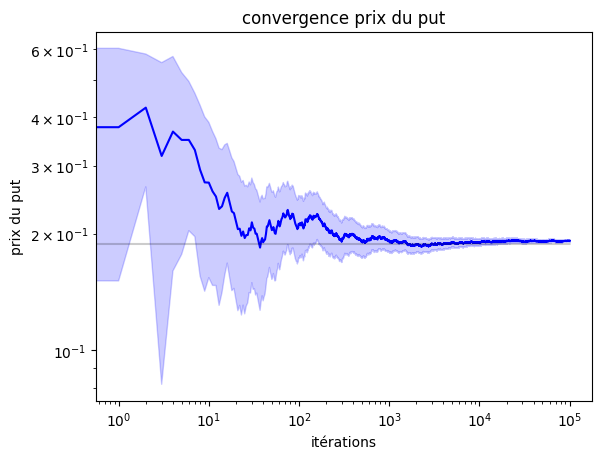

In [4]:
put=bsm_put(S, K, r, sigma,T, t)

put_t=np.maximum(K-S_t,0)
result([put_t],put,y_title="prix du put",global_title="convergence prix du put")

# 2.1 Pricing

------------------------------
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 0.0543744388104964
std: 0.0978921710759136
------------------------------


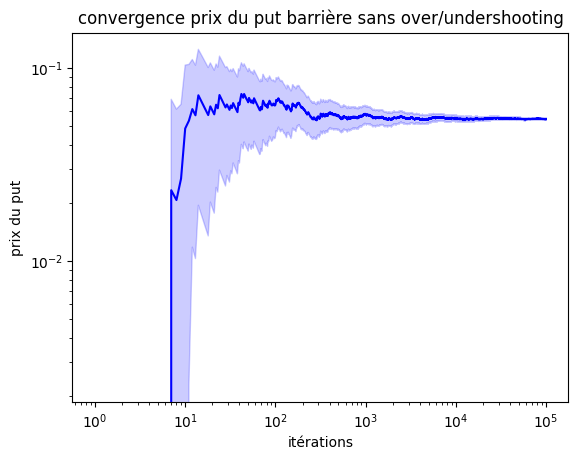

In [5]:
X_naive_t=put_t * ((S_t<L).cumsum(axis=1)<1).astype(int)
result([X_naive_t],y_title="prix du put",global_title="convergence prix du put barrière sans over/undershooting")

------------------------------
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 0.05191761321912181
std: 0.0943760657529911
------------------------------


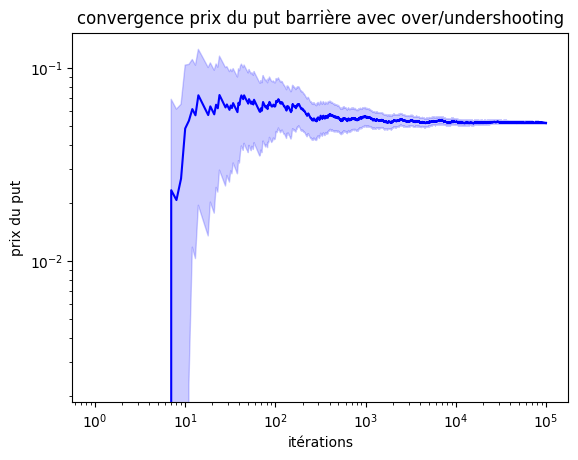

In [6]:
S_t_1=np.insert(S_t, 0, np.ones(S_t.shape[0]), axis=1)[:,:-1]
proba=1-np.exp(-(2*np.log(S_t_1/L)*np.log(S_t/L))/(sigma**2*dt))
proba[proba<0]=0
proba=proba.cumprod(axis=1)

X_corrected_t=X_naive_t*proba
result([X_corrected_t],y_title="prix du put",global_title="convergence prix du put barrière avec over/undershooting")

# 2.2 Réduction de variance

------------------------------
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 0.05191761321912181
std: 0.0943760657529911
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 0.05175352168379945
std: 0.09392265672819887
------------------------------


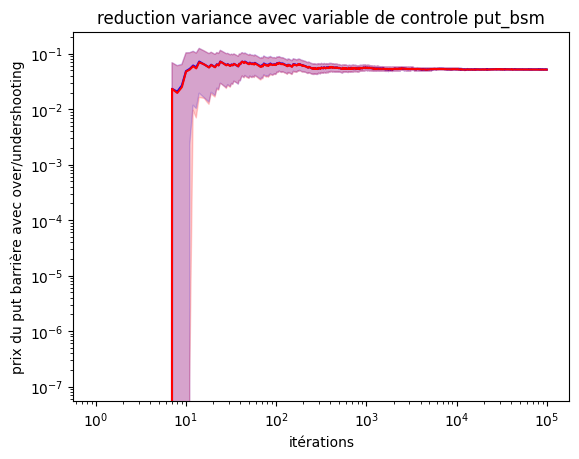

In [7]:
beta=get_beta(X_corrected_t,put_t-put)

func=lambda x,b: x-b*(put_t-put)

result([X_corrected_t,func(X_corrected_t,beta)],y_title="prix du put barrière avec over/undershooting",global_title="reduction variance avec variable de controle put_bsm")

------------------------------
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 0.05191761321912181
std: 0.0943760657529911
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 0.05187037543462177
std: 0.09211851605956603
------------------------------


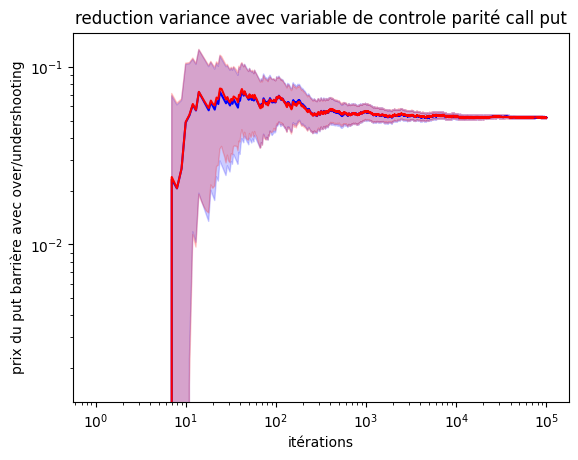

In [8]:
beta=get_beta(X_corrected_t,(np.exp(-r*(T-t))*S_t.transpose()[-1]-S)[:,np.newaxis])

func=lambda x,b: x-(b*(np.exp(-r*(T-t))*S_t.transpose()[-1]-S)[:,np.newaxis])

result([X_corrected_t,func(X_corrected_t,beta)],y_title="prix du put barrière avec over/undershooting",global_title="reduction variance avec variable de controle parité call put")

# 2.3 Sensibilité aux paramètres

In [9]:
K_l=np.linspace(0,4,11)
L_l=np.linspace(0,1,11)

In [10]:
m=1000
S_t = bsm_St(S,r,sigma,N,m,T,t)

In [11]:
X_naive_t= ((np.maximum(K_l[:, np.newaxis, np.newaxis]-S_t,0))[:,np.newaxis,:,:])*((((S_t<L_l[:,np.newaxis,np.newaxis]).cumsum(axis=2)<1).astype(int))[np.newaxis,:,:,:])

In [12]:
S_t_1=np.insert(S_t, 0, np.ones(S_t.shape[0]), axis=1)[:,:-1]
proba=1-np.exp(-(2*np.log(S_t_1[np.newaxis,:,:]/L_l[:,np.newaxis,np.newaxis])*np.log(S_t[np.newaxis,:,:]/L_l[:,np.newaxis,np.newaxis]))/(sigma**2*dt))

proba[proba<0]=0
proba=(proba.cumprod(axis=2))[np.newaxis,:,:,:]

In [13]:
S_t[np.newaxis,:,:].shape, L_l[:,np.newaxis,np.newaxis].shape

((1, 1000, 730), (11, 1, 1))

In [14]:
X_corrected_t=X_naive_t*proba

In [15]:
X_naive_t.shape

(11, 11, 1000, 730)

In [16]:
Z=((X_corrected_t*actualisation).transpose()[-1].cumsum(axis=0)/np.arange(1,m+1)[:,np.newaxis,np.newaxis])[-1].transpose()

In [17]:
X, Y = np.meshgrid(L_l, K_l)

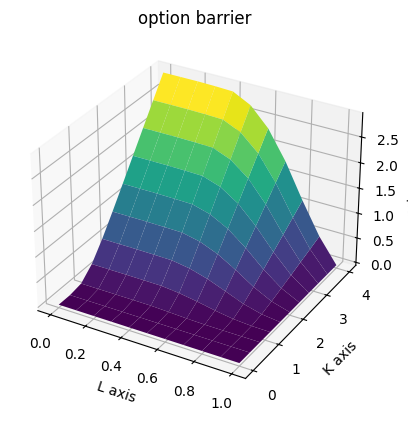

In [18]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(X, Y, Z, cmap='viridis')

# Set axis labels
ax.set_xlabel('L axis')
ax.set_ylabel('K axis')
ax.set_zlabel('price axis')
ax.set_title('option barrier')

# Show the plot
plt.show()